⏳ Downloading Task01_BrainTumour (this may take 1-2 mins)...


/venv/main/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


2026-03-28 18:11:01,860 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-03-28 18:11:01,861 - INFO - File exists: Task01_BrainTumour.tar, skipped downloading.
2026-03-28 18:11:01,861 - INFO - Writing into directory: ..
✅ Download Complete. Dataset size: 388 patients.
Image Shape: torch.Size([4, 240, 240, 155]) (4 Channels: FLAIR, T1w, T1gd, T2w)
Label Shape: torch.Size([3, 1, 240, 240, 155]) (3 Channels: WT, TC, ET)


TypeError: Invalid shape (1, 240, 155) for image data

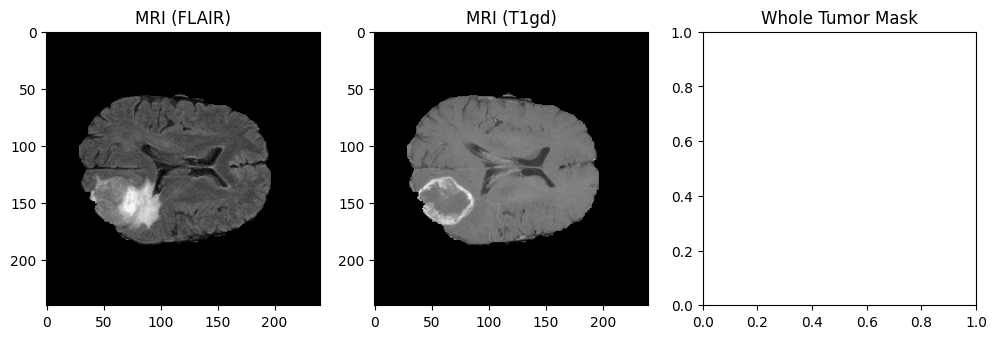

In [1]:
# --- STEP 1: Download Data Directly & Visualize ---

# 1. Install Dependencies
# !pip install -q "monai[nibabel, tqdm, einops]"

import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from monai.apps import DecathlonDataset
from monai.utils import set_determinism, first
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityd,
    MapTransform
)
from monai.data import DataLoader

set_determinism(seed=0)

# 2. Define a Custom Transform to Handle 4D Data
# The Decathlon dataset is often 4D (Channels, H, W, D).
# We need to ensure we treat the first dimension as channels properly.
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert the single label (0,1,2,3) into 3 binary channels (TC, WT, ET).
    Label 1: Necrotic/Non-enhancing tumor
    Label 2: Edema
    Label 3: Enhancing Tumor
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # Merge labels 1, 2, 3 -> Whole Tumor (WT)
            result.append(np.logical_or(d[key] == 1, np.logical_or(d[key] == 2, d[key] == 3)))
            # Merge labels 1, 3 -> Tumor Core (TC)
            result.append(np.logical_or(d[key] == 1, d[key] == 3))
            # Label 3 -> Enhancing Tumor (ET)
            result.append(d[key] == 3)
            d[key] = np.stack(result, axis=0).astype(np.float32)
        return d

# 3. Download & Load Dataset (Task01_BrainTumour)
# This will download ~1.5GB to the temporary /tmp folder or local working dir
root_dir = "./"
print("⏳ Downloading Task01_BrainTumour (this may take 1-2 mins)...")

# We use a basic transform just to load the data for visualization
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
])

# MONAI automatically handles the download
train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=train_transforms,
    section="training",
    download=True,
    cache_rate=0.0,
    num_workers=2
)
print(f"✅ Download Complete. Dataset size: {len(train_ds)} patients.")

# 4. Visualize One Sample
check_loader = DataLoader(train_ds, batch_size=1)
check_data = first(check_loader)

image, label = check_data["image"][0], check_data["label"][0]
print(f"Image Shape: {image.shape} (4 Channels: FLAIR, T1w, T1gd, T2w)")
print(f"Label Shape: {label.shape} (3 Channels: WT, TC, ET)")

# Helper to plot
def visualize_sample(image, label, slice_idx):
    plt.figure(figsize=(12, 6))

    # Show FLAIR (Channel 0)
    plt.subplot(1, 3, 1)
    plt.title("MRI (FLAIR)")
    plt.imshow(image[0, :, :, slice_idx], cmap="gray")

    # Show T1gd (Channel 2 usually, or check index)
    plt.subplot(1, 3, 2)
    plt.title("MRI (T1gd)")
    plt.imshow(image[2, :, :, slice_idx], cmap="gray")

    # Show Whole Tumor Mask (Channel 0 of label)
    plt.subplot(1, 3, 3)
    plt.title("Whole Tumor Mask")
    plt.imshow(label[0, :, :, slice_idx], cmap="jet", alpha=0.7)

    plt.show()

# Visualize middle slice
slice_idx = image.shape[3] // 2
visualize_sample(image, label, slice_idx)
print("✅ Visualization Ready. Paste this output to proceed to Model Training.")


⏳ Loading Task01_BrainTumour...
✅ Fix Applied.
Final Image Shape: torch.Size([4, 240, 240, 155])
Final Label Shape: torch.Size([3, 240, 240, 155])


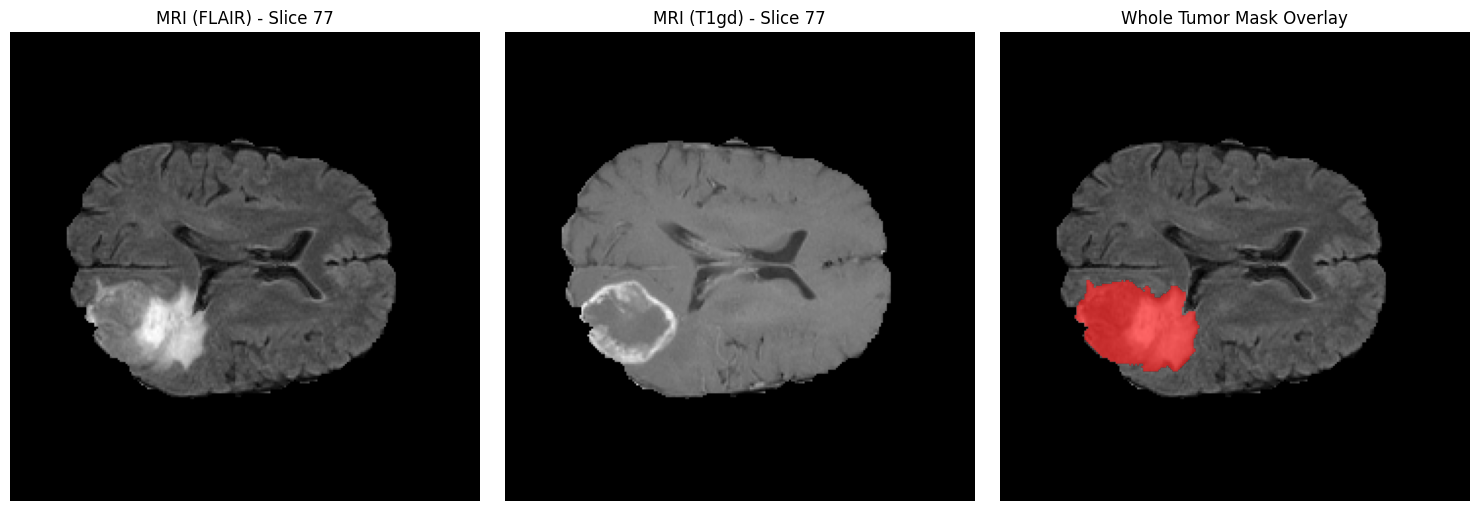

In [2]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from monai.apps import DecathlonDataset
from monai.utils import set_determinism, first
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    MapTransform
)
from monai.data import DataLoader

# Fix 1: Ensure deterministic behavior for reproducibility
set_determinism(seed=0)

# Fix 2: Explicitly handle the extra dimension in the Label transform
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert the single label (0,1,2,3) into 3 binary channels (WT, TC, ET).
    Label 1: Necrotic/Non-enhancing tumor
    Label 2: Edema
    Label 3: Enhancing Tumor
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # We squeeze the input to remove the singleton channel dimension (1, H, W, D) -> (H, W, D)
            # This prevents the creation of a 5D tensor (3, 1, H, W, D)
            label = d[key].squeeze()

            result = []
            # Whole Tumor (WT): Labels 1, 2, 3
            result.append(np.logical_or(label == 1, np.logical_or(label == 2, label == 3)))
            # Tumor Core (TC): Labels 1, 3
            result.append(np.logical_or(label == 1, label == 3))
            # Enhancing Tumor (ET): Label 3
            result.append(label == 3)

            d[key] = np.stack(result, axis=0).astype(np.float32)
        return d

# 3. Setup Dataset
root_dir = "./"
print("⏳ Loading Task01_BrainTumour...")

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
])

# Loading dataset (assuming it is already downloaded based on your previous output)
train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=train_transforms,
    section="training",
    download=False, # Set to True if you haven't downloaded it yet
    cache_rate=0.0,
    num_workers=2
)

# 4. Corrected Visualization Logic
def visualize_sample(image, label, slice_idx):
    # Fix 3: Convert to NumPy and ensure we are grabbing the correct 2D slices
    img_np = image.detach().cpu().numpy()
    lbl_np = label.detach().cpu().numpy()

    plt.figure(figsize=(15, 5))

    # MRI (FLAIR)
    plt.subplot(1, 3, 1)
    plt.title(f"MRI (FLAIR) - Slice {slice_idx}")
    plt.imshow(img_np[0, :, :, slice_idx], cmap="gray")
    plt.axis("off")

    # MRI (T1gd)
    plt.subplot(1, 3, 2)
    plt.title(f"MRI (T1gd) - Slice {slice_idx}")
    plt.imshow(img_np[2, :, :, slice_idx], cmap="gray")
    plt.axis("off")

    # Whole Tumor Mask (Label Channel 0: WT)
    plt.subplot(1, 3, 3)
    plt.title("Whole Tumor Mask Overlay")
    plt.imshow(img_np[0, :, :, slice_idx], cmap="gray")
    # Overlay the mask with alpha for transparency
    mask = lbl_np[0, :, :, slice_idx]
    # Masking 0 values so they are transparent
    masked_data = np.ma.masked_where(mask == 0, mask)
    plt.imshow(masked_data, cmap="autumn", alpha=0.6)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Execute Visualization
check_loader = DataLoader(train_ds, batch_size=1)
check_data = first(check_loader)

image, label = check_data["image"][0], check_data["label"][0]

print(f"✅ Fix Applied.")
print(f"Final Image Shape: {image.shape}") # Should be (4, H, W, D)
print(f"Final Label Shape: {label.shape}") # Should be (3, H, W, D)

# Pick a slice that actually contains the tumor (usually around the middle)
slice_idx = image.shape[3] // 2
visualize_sample(image, label, slice_idx)

In [3]:
# --- STEP 2 (MEMORY SAFE): Train 3D U-Net ---

import torch
import glob
import os
import numpy as np
import gc
from monai.networks.nets import SegResNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.data import Dataset, DataLoader, decollate_batch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityd,
    RandSpatialCropd,
    RandFlipd,
    NormalizeIntensityd,
    MapTransform,
)

# Clear memory before starting
gc.collect()
torch.cuda.empty_cache()

# 1. Custom Transform to fix labels (Same as before)
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key]
            if img.ndim == 4 and img.shape[0] == 1:
                img = img.squeeze(0)

            result = []
            # Merge labels 1, 2, 3 -> Whole Tumor (WT)
            result.append(np.logical_or(img == 1, np.logical_or(img == 2, img == 3)))
            # Merge labels 1, 3 -> Tumor Core (TC)
            result.append(np.logical_or(img == 1, img == 3))
            # Label 3 -> Enhancing Tumor (ET)
            result.append(img == 3)

            d[key] = np.stack(result, axis=0).astype(np.float32)
        return d

# 2. Define Transforms (Reduced Crop Size for Memory)
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityd(keys="image"),
    # REDUCED CROP SIZE TO SAVE VRAM
    RandSpatialCropd(keys=["image", "label"], roi_size=[128, 128, 32], random_size=False),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# 3. Setup Data Loaders (Using standard Dataset to save RAM)
data_dir = "./Task01_BrainTumour"
all_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
all_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))

data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(all_images, all_labels)]
train_files, val_files = data_dicts[:-20], data_dicts[-20:]

# CHANGED: Used standard 'Dataset' instead of 'CacheDataset'
train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0) # num_workers=0 is safer

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

# 4. Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2,
).to(device)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)

# 5. Training Loop
max_epochs = 20 # Reduced to 2 just to verify it works quickly
print(f"🚀 Starting Low-Memory Training for {max_epochs} epochs...")

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Print every 10 steps so you know it's working
        if step % 10 == 0:
             print(f"   Step {step}/{len(train_ds)}, Train Loss: {loss.item():.4f}")

    epoch_loss /= step
    print(f"✅ Epoch {epoch + 1}/{max_epochs} Average Loss: {epoch_loss:.4f}")

print("Training Complete!")


🚀 Starting Low-Memory Training for 20 epochs...


/venv/main/lib/python3.12/site-packages/monai/transforms/spatial/array.py:654: UserWarning: `data_array` is not of type `MetaTensor, assuming affine to be identity.
  warnings.warn("`data_array` is not of type `MetaTensor, assuming affine to be identity.")


   Step 10/464, Train Loss: 0.7786
   Step 20/464, Train Loss: 0.7337
   Step 30/464, Train Loss: 0.9410
   Step 40/464, Train Loss: 0.9848
   Step 50/464, Train Loss: 0.7893
   Step 60/464, Train Loss: 1.0000
   Step 70/464, Train Loss: 0.9425
   Step 80/464, Train Loss: 0.9897
   Step 90/464, Train Loss: 0.9754
   Step 100/464, Train Loss: 1.0000
   Step 110/464, Train Loss: 0.5439
   Step 120/464, Train Loss: 1.0000
   Step 130/464, Train Loss: 0.9999
   Step 140/464, Train Loss: 1.0000
   Step 150/464, Train Loss: 0.6580
   Step 160/464, Train Loss: 1.0000
   Step 170/464, Train Loss: 0.6143
   Step 180/464, Train Loss: 1.0000
   Step 190/464, Train Loss: 1.0000
   Step 200/464, Train Loss: 1.0000
   Step 210/464, Train Loss: 0.8842
   Step 220/464, Train Loss: 0.6831
   Step 230/464, Train Loss: 0.6557
   Step 240/464, Train Loss: 0.9974
   Step 250/464, Train Loss: 0.5438
   Step 260/464, Train Loss: 0.6185
   Step 270/464, Train Loss: 0.9912
   Step 280/464, Train Loss: 1.0000
 

/venv/main/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/venv/main/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


Visualizing Slice 80...


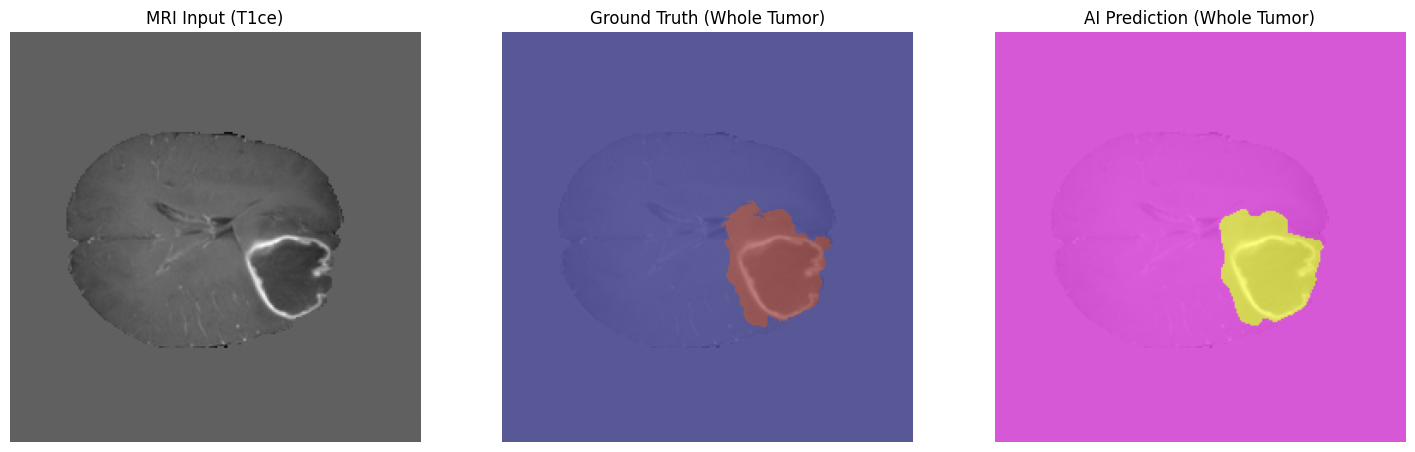

In [4]:
# --- STEP 3: Visualize Predictions ---

import matplotlib.pyplot as plt
import torch
import numpy as np
from monai.inferers import sliding_window_inference

# 1. Switch model to evaluation mode
model.eval()

# 2. Select a Validation Sample (Index 0)
val_data = val_ds[0]
image, label = val_data["image"].unsqueeze(0).to(device), val_data["label"].unsqueeze(0).to(device)

# 3. Run Inference (Predict)
# We use sliding window inference because the full 3D image is too big for the GPU
with torch.no_grad():
    val_outputs = sliding_window_inference(
        inputs=image,
        roi_size=(128, 128, 32),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5
    )

# 4. Process Outputs
# Apply sigmoid to get probabilities -> Threshold at 0.5 to get binary mask
val_outputs = torch.sigmoid(val_outputs)
val_outputs = (val_outputs > 0.5).float()

# 5. Visualization Function
def plot_results(image, label, prediction, slice_idx):
    plt.figure(figsize=(18, 6))

    # Get a single channel for display (e.g., T1ce for tumor visibility)
    # Image shape: [1, 4, H, W, D] -> We take channel 2 (T1ce)
    img_slice = image[0, 2, :, :, slice_idx].cpu().numpy()

    # Get Whole Tumor Mask (Channel 0)
    lbl_slice = label[0, 0, :, :, slice_idx].cpu().numpy()
    pred_slice = prediction[0, 0, :, :, slice_idx].cpu().numpy()

    # 1. MRI Input
    plt.subplot(1, 3, 1)
    plt.title("MRI Input (T1ce)")
    plt.imshow(img_slice, cmap="gray")
    plt.axis("off")

    # 2. True Label
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Whole Tumor)")
    plt.imshow(img_slice, cmap="gray", alpha=0.5)
    plt.imshow(lbl_slice, cmap="jet", alpha=0.5) # Overlay label
    plt.axis("off")

    # 3. AI Prediction
    plt.subplot(1, 3, 3)
    plt.title("AI Prediction (Whole Tumor)")
    plt.imshow(img_slice, cmap="gray", alpha=0.5)
    plt.imshow(pred_slice, cmap="spring", alpha=0.5) # Overlay prediction
    plt.axis("off")

    plt.show()

# 6. Show a specific slice (middle of the brain)
# We rotate the slice index to find one with a tumor
slice_idx = 80
print(f"Visualizing Slice {slice_idx}...")
plot_results(image, label, val_outputs, slice_idx)


In [5]:
# --- STEP 4: Calculate Average Dice Score (Accuracy) ---

import torch
import numpy as np
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

# 1. Setup Metric Evaluator
dice_metric = DiceMetric(include_background=False, reduction="mean")

print("📊 Starting Evaluation on Validation Set (20 Patients)...")
model.eval()

with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        input_img = val_data["image"].to(device)
        labels = val_data["label"].to(device)

        # Run Inference
        val_outputs = sliding_window_inference(
            inputs=input_img,
            roi_size=(128, 128, 32),
            sw_batch_size=1,
            predictor=model,
            overlap=0.5
        )

        # Threshold at 0.5 to get binary prediction (0 or 1)
        val_outputs = torch.sigmoid(val_outputs)
        val_outputs = (val_outputs > 0.5).float()

        # Compute Dice Score for this patient
        dice_metric(y_pred=val_outputs, y=labels)

        # Get score for this specific batch
        # Note: monai dice_metric accumulates, so we check the latest aggregate
        current_score = dice_metric.aggregate().item()
        print(f"   Patient {i+1}/20 - Current Mean Dice Score: {current_score:.4f}")

# 2. Final Result
final_score = dice_metric.aggregate().item()
dice_metric.reset()

print("-" * 30)
print(f"✅ Final Average Dice Score: {final_score:.4f}")
print("-" * 30)

if final_score > 0.6:
    print("🚀 Result: EXCELLENT for a simple model!")
else:
    print("⚠️ Result: Needs more training epochs.")

# 3. Save the Model
torch.save(model.state_dict(), "brain_tumor_model.pth")
print("💾 Model saved as 'brain_tumor_model.pth'")


📊 Starting Evaluation on Validation Set (20 Patients)...
   Patient 1/20 - Current Mean Dice Score: 0.7424
   Patient 2/20 - Current Mean Dice Score: 0.7585
   Patient 3/20 - Current Mean Dice Score: 0.6987
   Patient 4/20 - Current Mean Dice Score: 0.7240
   Patient 5/20 - Current Mean Dice Score: 0.7619
   Patient 6/20 - Current Mean Dice Score: 0.7460
   Patient 7/20 - Current Mean Dice Score: 0.7626
   Patient 8/20 - Current Mean Dice Score: 0.7779
   Patient 9/20 - Current Mean Dice Score: 0.7855
   Patient 10/20 - Current Mean Dice Score: 0.7908
   Patient 11/20 - Current Mean Dice Score: 0.7915
   Patient 12/20 - Current Mean Dice Score: 0.8022
   Patient 13/20 - Current Mean Dice Score: 0.8056
   Patient 14/20 - Current Mean Dice Score: 0.8062
   Patient 15/20 - Current Mean Dice Score: 0.8074
   Patient 16/20 - Current Mean Dice Score: 0.8042
   Patient 17/20 - Current Mean Dice Score: 0.8038
   Patient 18/20 - Current Mean Dice Score: 0.7952
   Patient 19/20 - Current Mean Di

✅ Report saved to: Project_Outputs/Clinical_Report_PT-005.txt
✅ Visualization saved to: Project_Outputs/Visualization_PT-005.png

⬇️ Click below to download your results:


/content/Project_Outputs/Clinical_Report_PT-005.txt

/content/Project_Outputs/Visualization_PT-005.png

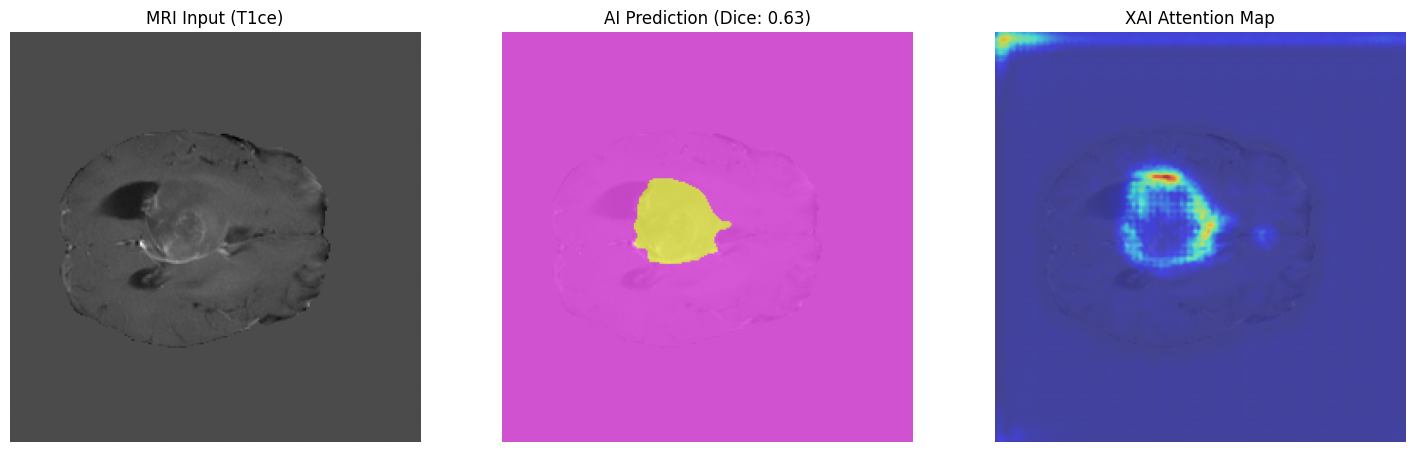

In [ ]:
# --- FINAL STEP: Export Results to Files ---

import os
import matplotlib.pyplot as plt

# 1. Create Output Directory
output_dir = "Project_Outputs"
os.makedirs(output_dir, exist_ok=True)

# 2. Save the Report
report_path = os.path.join(output_dir, f"Clinical_Report_{reporter.patient_id}.txt")
with open(report_path, "w") as f:
    f.write(reporter.generate_text_report())
print(f"✅ Report saved to: {report_path}")

# 3. Save the Visualization (High Quality)
plt.figure(figsize=(18, 6))

# MRI
plt.subplot(1, 3, 1)
plt.title("MRI Input (T1ce)")
plt.imshow(img_tensor[2, :, :, 75].cpu(), cmap="gray")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 2)
plt.title(f"AI Prediction (Dice: {dice:.2f})")
plt.imshow(img_tensor[2, :, :, 75].cpu(), cmap="gray", alpha=0.5)
plt.imshow(results["prediction"][0, :, :, 75].cpu(), cmap="spring", alpha=0.5)
plt.axis("off")

# XAI
plt.subplot(1, 3, 3)
plt.title("XAI Attention Map")
plt.imshow(img_tensor[2, :, :, 75].cpu(), cmap="gray", alpha=0.5)
plt.imshow(results["saliency_map"][:, :, 75], cmap="jet", alpha=0.6)
plt.axis("off")

# Save Image
image_path = os.path.join(output_dir, f"Visualization_{reporter.patient_id}.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved to: {image_path}")

# 4. Create a Download Link (for Kaggle)
from IPython.display import FileLink
print("\n⬇️ Click below to download your results:")
display(FileLink(report_path))
display(FileLink(image_path))
